# NB02: Hypothetical Resolution

How many RAST/Bakta "hypothetical protein" genes does the AI agent resolve with a specific function? Are resolved hypotheticals enriched in specific phenotype categories?

**Key questions:**
1. How many hypotheticals from each source does the agent resolve?
2. When RAST/Bakta and agent both give a function, do they agree?
3. What genes get genuinely new functional information from the agent?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if 'adp1_annotation_reassessment' not in PROJECT_DIR:
    PROJECT_DIR = 'projects/adp1_annotation_reassessment'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

master = pd.read_csv(os.path.join(PROJECT_DIR, 'data/master_annotation_table.csv'))
print(f'Master table: {len(master)} genes')

# Focus on protein-coding genes (those with any annotation from any source)
proteins = master[master[['rast_function', 'bakta_function', 'agent_annotation']].notna().any(axis=1)].copy()
print(f'Protein-coding genes (any annotation): {len(proteins)}')

Master table: 5852 genes
Protein-coding genes (any annotation): 3235


## Hypothetical Resolution Rates

In [2]:
# RAST hypotheticals resolved by agent
rast_hypo = proteins[proteins['rast_class'] == 'hypothetical']
rast_hypo_resolved = rast_hypo[rast_hypo['agent_class'] == 'specific']
print(f'RAST hypotheticals: {len(rast_hypo)}')
print(f'  Resolved by agent: {len(rast_hypo_resolved)} ({len(rast_hypo_resolved)/len(rast_hypo)*100:.1f}%)')

# Bakta hypotheticals resolved by agent
bakta_hypo = proteins[proteins['bakta_class'] == 'hypothetical']
bakta_hypo_resolved = bakta_hypo[bakta_hypo['agent_class'] == 'specific']
print(f'\nBakta hypotheticals: {len(bakta_hypo)}')
print(f'  Resolved by agent: {len(bakta_hypo_resolved)} ({len(bakta_hypo_resolved)/len(bakta_hypo)*100:.1f}%)')

# Both RAST and Bakta hypothetical, resolved by agent
both_hypo = proteins[(proteins['rast_class'] == 'hypothetical') & (proteins['bakta_class'] == 'hypothetical')]
both_hypo_resolved = both_hypo[both_hypo['agent_class'] == 'specific']
print(f'\nBoth RAST+Bakta hypothetical: {len(both_hypo)}')
print(f'  Resolved by agent: {len(both_hypo_resolved)} ({len(both_hypo_resolved)/len(both_hypo)*100:.1f}%)')

# RAST missing but agent provides annotation
rast_missing = proteins[proteins['rast_class'] == 'missing']
rast_missing_resolved = rast_missing[rast_missing['agent_class'] == 'specific']
print(f'\nRAST missing: {len(rast_missing)}')
print(f'  Agent provides specific annotation: {len(rast_missing_resolved)}')

RAST hypotheticals: 432
  Resolved by agent: 264 (61.1%)

Bakta hypotheticals: 270
  Resolved by agent: 158 (58.5%)

Both RAST+Bakta hypothetical: 209
  Resolved by agent: 120 (57.4%)

RAST missing: 0
  Agent provides specific annotation: 0


In [3]:
# Show some examples of resolved hypotheticals
print('Examples of RAST hypotheticals resolved by agent:')
print('=' * 100)
examples = rast_hypo_resolved.head(10)
for _, row in examples.iterrows():
    print(f'  {row["feature_id"]} ({row["old_locus_tag"]})')
    print(f'    RAST:  {row["rast_function"]}')
    print(f'    Bakta: {row["bakta_function"]}')
    print(f'    Agent: {row["agent_annotation"][:120]}...' if len(str(row["agent_annotation"])) > 120 else f'    Agent: {row["agent_annotation"]}')
    print()

Examples of RAST hypotheticals resolved by agent:
  ACIAD_RS16620 (ACIAD3677)
    RAST:  hypothetical protein
    Bakta: N-acetyltransferase domain-containing protein
    Agent: Likely accessory protein in a chaperone–usher (type 1 fimbrial) pilus operon, implicated in fimbriae/adhesin assembly an...

  ACIAD_RS16605 (ACIAD3674)
    RAST:  hypothetical protein
    Bakta: N-acetyltransferase domain-containing protein
    Agent: Predicted GNAT-like acyl-CoA–dependent N-acyltransferase that acetylates amine-containing metabolites, impacting carbon/...

  ACIAD_RS16510 (ACIAD3649)
    RAST:  hypothetical protein
    Bakta: Lipoprotein
    Agent: Cyanophycin-associated protein (cphX-like), likely involved in cyanophycin nitrogen-storage polymer synthesis/accumulati...

  ACIAD_RS16345 (ACIAD3614)
    RAST:  hypothetical protein
    Bakta: Lipoprotein
    Agent: Short-chain acyl-CoA dehydrogenase involved in branched-chain amino acid (especially isoleucine) catabolism, likely oxid...

  ACIA

## Are Resolved Hypotheticals Enriched in Phenotype Categories?

We compare essentiality rates between resolved and unresolved hypotheticals. A naive growth-defect
threshold (fitness < 0.5 on any single condition) is too permissive and classifies nearly all genes
as defective, so we focus on the cleaner categorical essentiality variable instead.

In [4]:
# Compare resolved vs unresolved hypotheticals on essentiality and severe growth defects.
# Note: a permissive threshold like fitness < 0.5 on ANY condition classifies ~97% of genes
# as having a "defect", making the comparison uninformative. Instead we use:
# 1. The categorical essentiality variable (cleaner)
# 2. A stringent defect definition: fitness < 0.3 on >=2 conditions (severe, multi-condition)

growth_cols = [c for c in proteins.columns if c.startswith('mutant_growth_')]
has_growth = proteins[growth_cols].notna().any(axis=1)

# Stringent growth defect: fitness < 0.3 on at least 2 conditions
severe_defect = ((proteins[growth_cols] < 0.3).sum(axis=1) >= 2) & has_growth

resolved_severe = severe_defect.loc[rast_hypo_resolved.index].sum()
resolved_with_growth = has_growth.loc[rast_hypo_resolved.index].sum()

unresolved_idx = rast_hypo.index.difference(rast_hypo_resolved.index)
unresolved_severe = severe_defect.loc[unresolved_idx].sum()
unresolved_with_growth = has_growth.loc[unresolved_idx].sum()

print('Severe growth defect (fitness < 0.3 on >=2 conditions):')
print(f'  Resolved hypotheticals: {resolved_severe}/{resolved_with_growth} ({resolved_severe/max(resolved_with_growth,1)*100:.1f}%)')
print(f'  Unresolved hypotheticals: {unresolved_severe}/{unresolved_with_growth} ({unresolved_severe/max(unresolved_with_growth,1)*100:.1f}%)')

# Essentiality comparison (primary metric)
resolved_ess_rate = (rast_hypo_resolved['essentiality_minimal'] == 'essential').sum() / len(rast_hypo_resolved)
unresolved_ess_rate = (rast_hypo[~rast_hypo.index.isin(rast_hypo_resolved.index)]['essentiality_minimal'] == 'essential').sum() / len(rast_hypo[~rast_hypo.index.isin(rast_hypo_resolved.index)])
print(f'\nEssentiality rate:')
print(f'  Resolved hypotheticals: {resolved_ess_rate:.1%}')
print(f'  Unresolved hypotheticals: {unresolved_ess_rate:.1%}')

Severe growth defect (fitness < 0.3 on >=2 conditions):
  Resolved hypotheticals: 0/187 (0.0%)
  Unresolved hypotheticals: 0/125 (0.0%)

Essentiality rate:
  Resolved hypotheticals: 4.2%
  Unresolved hypotheticals: 2.4%


In [5]:
# Essentiality enrichment
resolved_essential = rast_hypo_resolved['essentiality_minimal'].value_counts()
unresolved_hypo = rast_hypo[~rast_hypo.index.isin(rast_hypo_resolved.index)]
unresolved_essential = unresolved_hypo['essentiality_minimal'].value_counts()

print('Essentiality among RAST hypotheticals resolved by agent:')
print(resolved_essential)
print(f'\nEssentiality among unresolved RAST hypotheticals:')
print(unresolved_essential)

Essentiality among RAST hypotheticals resolved by agent:
essentiality_minimal
dispensable    226
uncertain       18
essential       11
Name: count, dtype: int64

Essentiality among unresolved RAST hypotheticals:
essentiality_minimal
dispensable    142
uncertain       11
essential        4
Name: count, dtype: int64


## Agreement Analysis: When Both Give a Function, Do They Agree?

For genes where both RAST and agent provide a specific annotation, assess agreement using keyword overlap.

In [6]:
import re

def extract_keywords(ann):
    """Extract meaningful keywords from an annotation string."""
    if pd.isna(ann):
        return set()
    ann = str(ann).lower()
    # Remove EC numbers, parenthetical qualifiers
    ann = re.sub(r'\(ec\s+[\d\.\-]+\)', '', ann)
    ann = re.sub(r'\(.*?\)', '', ann)
    # Tokenize
    words = set(re.findall(r'[a-z]{3,}', ann))
    # Remove stopwords
    stopwords = {'the', 'and', 'for', 'with', 'that', 'this', 'from', 'are', 'was', 'were',
                 'protein', 'family', 'domain', 'containing', 'related', 'like', 'type',
                 'putative', 'probable', 'predicted', 'possible', 'subunit'}
    return words - stopwords

def annotation_similarity(ann1, ann2):
    """Compute Jaccard similarity between annotation keyword sets."""
    kw1 = extract_keywords(ann1)
    kw2 = extract_keywords(ann2)
    if not kw1 or not kw2:
        return 0.0
    return len(kw1 & kw2) / len(kw1 | kw2)

# Both RAST and agent specific
both_specific = proteins[(proteins['rast_class'] == 'specific') & (proteins['agent_class'] == 'specific')].copy()
print(f'Genes with both RAST and agent specific annotation: {len(both_specific)}')

both_specific['similarity'] = both_specific.apply(
    lambda row: annotation_similarity(row['rast_function'], row['agent_annotation']), axis=1
)

print(f'\nSimilarity statistics:')
print(both_specific['similarity'].describe())

# Categorize
both_specific['agreement'] = pd.cut(
    both_specific['similarity'],
    bins=[-0.01, 0.0, 0.2, 0.5, 1.01],
    labels=['No overlap', 'Low', 'Moderate', 'High']
)
print(f'\nAgreement categories:')
print(both_specific['agreement'].value_counts())

Genes with both RAST and agent specific annotation: 2720

Similarity statistics:
count    2720.000000
mean        0.119931
std         0.112479
min         0.000000
25%         0.037037
50%         0.100000
75%         0.178571
max         1.000000
Name: similarity, dtype: float64

Agreement categories:
agreement
Low           1563
No overlap     652
Moderate       490
High            15
Name: count, dtype: int64


In [7]:
# Show examples of disagreements (low similarity)
disagreements = both_specific[both_specific['similarity'] < 0.1].head(10)
print('Examples of RAST vs Agent disagreements (low keyword overlap):')
print('=' * 120)
for _, row in disagreements.iterrows():
    print(f'  {row["feature_id"]} ({row["old_locus_tag"]})')
    print(f'    RAST:  {row["rast_function"]}')
    agent_short = str(row['agent_annotation'])[:150]
    print(f'    Agent: {agent_short}' + ('...' if len(str(row['agent_annotation'])) > 150 else ''))
    print()

Examples of RAST vs Agent disagreements (low keyword overlap):
  ACIAD_RS16655 (nan)
    RAST:  LSU ribosomal protein L34p
    Agent: 50S ribosomal protein bL34, a small basic component of the large ribosomal subunit important for efficient translation; mutants show altered fitness u...

  ACIAD_RS16650 (nan)
    RAST:  Ribonuclease P protein component (EC 3.1.26.5)
    Agent: Protein subunit of bacterial RNase P that binds the catalytic RNase P RNA and promotes 5′-end processing of precursor tRNAs (tRNA maturation).

  ACIAD_RS16635 (nan)
    RAST:  tRNA-5-carboxymethylaminomethyl-2-thiouridine(34) synthesis protein MnmE
    Agent: tRNA-modifying P-loop GTPase MnmE (TrmE), which with MnmG catalyzes formation of the mnm5 group on wobble uridine (U34) in multiple tRNAs to support e...

  ACIAD_RS16615 (ACIAD3676)
    RAST:  Homolog of plant auxin-responsive GH3-like protein
    Agent: Glycoside hydrolase family 3 (GH3) enzyme, likely a beta-N-acetylglucosaminidase/beta-glucosidase that 

In [8]:
# Also compare Bakta vs Agent
both_bakta_agent = proteins[(proteins['bakta_class'] == 'specific') & (proteins['agent_class'] == 'specific')].copy()
both_bakta_agent['similarity'] = both_bakta_agent.apply(
    lambda row: annotation_similarity(row['bakta_function'], row['agent_annotation']), axis=1
)

print(f'Bakta vs Agent agreement ({len(both_bakta_agent)} genes):')
print(both_bakta_agent['similarity'].describe())

Bakta vs Agent agreement (2826 genes):
count    2826.000000
mean        0.116357
std         0.112409
min         0.000000
25%         0.000000
50%         0.095238
75%         0.176471
max         1.000000
Name: similarity, dtype: float64


## Hypothetical Resolution Figures

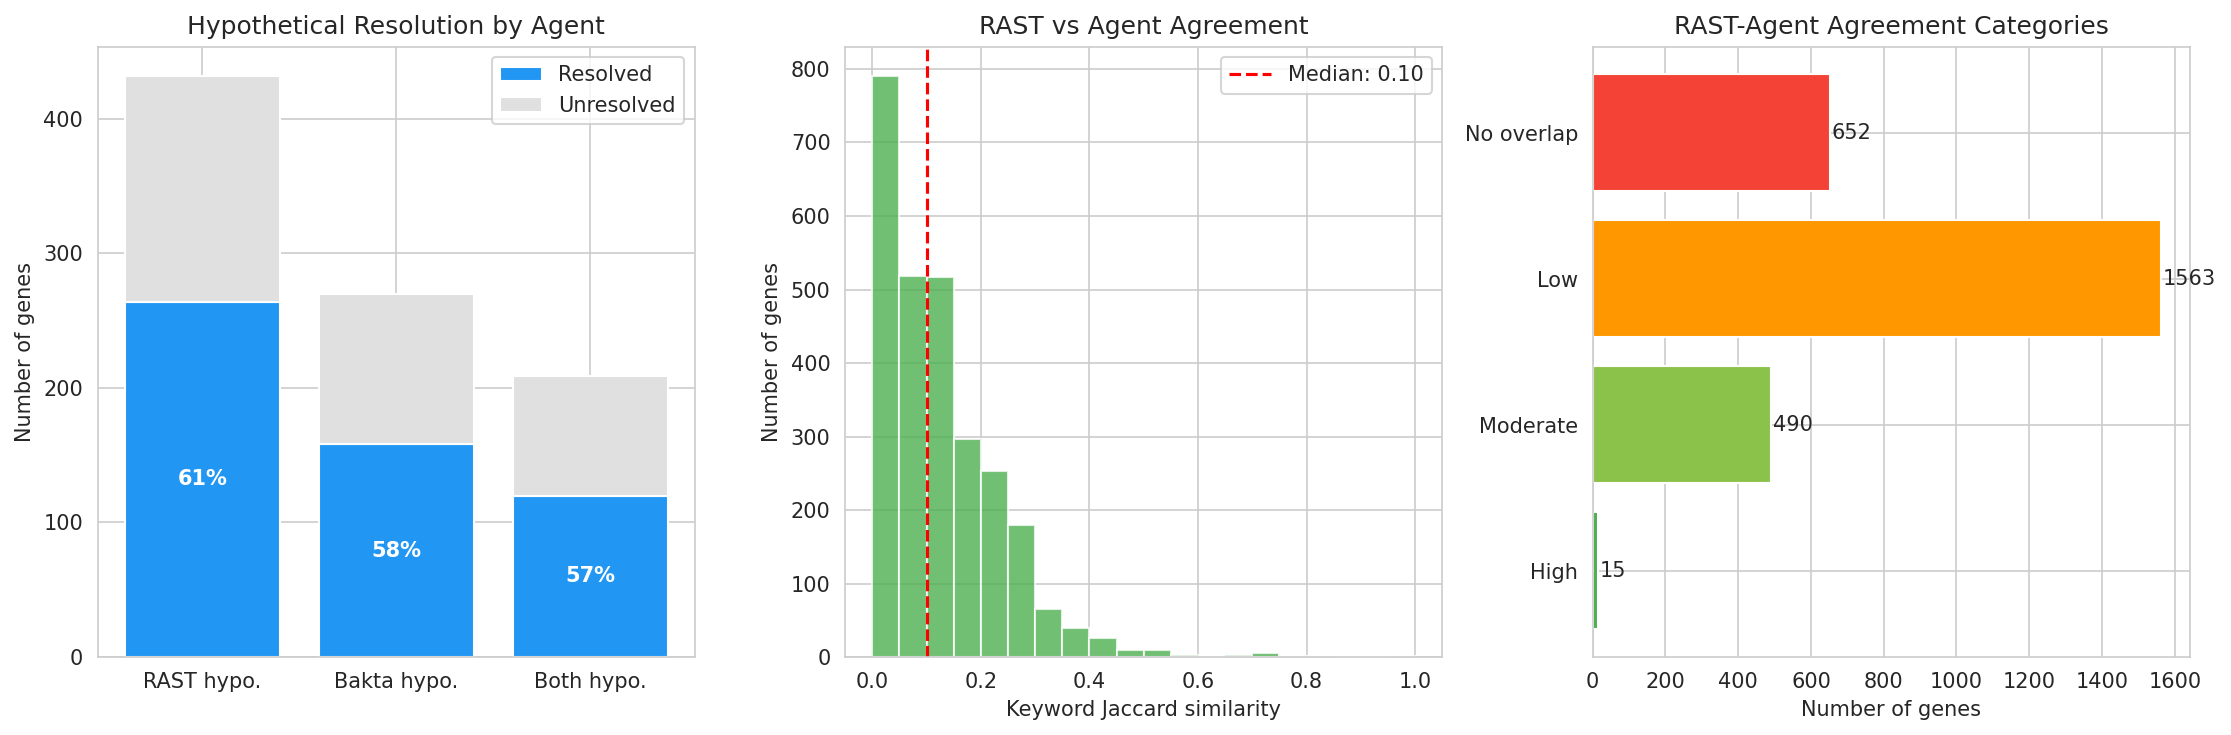

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Resolution rates
resolution_data = pd.DataFrame({
    'Source': ['RAST hypo.', 'Bakta hypo.', 'Both hypo.'],
    'Total': [len(rast_hypo), len(bakta_hypo), len(both_hypo)],
    'Resolved': [len(rast_hypo_resolved), len(bakta_hypo_resolved), len(both_hypo_resolved)]
})
resolution_data['Unresolved'] = resolution_data['Total'] - resolution_data['Resolved']
resolution_data['Rate (%)'] = (resolution_data['Resolved'] / resolution_data['Total'] * 100).round(1)

ax = axes[0]
bars = ax.bar(resolution_data['Source'], resolution_data['Resolved'], color='#2196F3', label='Resolved')
ax.bar(resolution_data['Source'], resolution_data['Unresolved'], bottom=resolution_data['Resolved'],
       color='#E0E0E0', label='Unresolved')
for i, (_, row) in enumerate(resolution_data.iterrows()):
    ax.text(i, row['Resolved'] / 2, f"{row['Rate (%)']:.0f}%", ha='center', va='center', fontweight='bold', color='white')
ax.set_ylabel('Number of genes')
ax.set_title('Hypothetical Resolution by Agent')
ax.legend()

# Panel 2: RAST vs Agent similarity distribution
ax = axes[1]
ax.hist(both_specific['similarity'], bins=20, color='#4CAF50', edgecolor='white', alpha=0.8)
ax.axvline(both_specific['similarity'].median(), color='red', linestyle='--', label=f'Median: {both_specific["similarity"].median():.2f}')
ax.set_xlabel('Keyword Jaccard similarity')
ax.set_ylabel('Number of genes')
ax.set_title('RAST vs Agent Agreement')
ax.legend()

# Panel 3: Agreement categories
ax = axes[2]
agreement_counts = both_specific['agreement'].value_counts().reindex(['High', 'Moderate', 'Low', 'No overlap'])
colors = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336']
ax.barh(agreement_counts.index, agreement_counts.values, color=colors)
for i, v in enumerate(agreement_counts.values):
    ax.text(v + 5, i, str(v), va='center')
ax.set_xlabel('Number of genes')
ax.set_title('RAST-Agent Agreement Categories')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures/hypothetical_resolution.png'), dpi=150, bbox_inches='tight')
plt.show()

## Summary: Genes with Genuinely New Functional Information

In [10]:
# Genes where agent provides specific annotation but RAST does not
agent_new_vs_rast = proteins[
    (proteins['agent_class'] == 'specific') &
    (proteins['rast_class'].isin(['hypothetical', 'missing']))
]
print(f'Agent provides new info vs RAST: {len(agent_new_vs_rast)} genes')

# Genes where agent provides specific annotation but neither RAST nor Bakta do
agent_new_vs_both = proteins[
    (proteins['agent_class'] == 'specific') &
    (proteins['rast_class'].isin(['hypothetical', 'missing'])) &
    (proteins['bakta_class'].isin(['hypothetical', 'missing']))
]
print(f'Agent provides new info vs BOTH RAST and Bakta: {len(agent_new_vs_both)} genes')

# Save these for downstream analysis
agent_new_vs_both.to_csv(os.path.join(PROJECT_DIR, 'data/agent_unique_annotations.csv'), index=False)
print(f'\nSaved agent-unique annotations to data/agent_unique_annotations.csv')

# Show some examples
print(f'\nExamples of genes with agent-only specific annotation:')
for _, row in agent_new_vs_both.head(10).iterrows():
    print(f'  {row["feature_id"]} ({row["old_locus_tag"]}): {str(row["agent_annotation"])[:100]}')

Agent provides new info vs RAST: 264 genes
Agent provides new info vs BOTH RAST and Bakta: 120 genes

Saved agent-unique annotations to data/agent_unique_annotations.csv

Examples of genes with agent-only specific annotation:
  ACIAD_RS16145 (ACIAD3568): Glutathione-dependent maleylacetoacetate isomerase (HmgB)-like enzyme involved in homogentisate path
  ACIAD_RS15935 (nan): Putative MesX family protein, a component of the MesXYZ alternative methionine synthase system impli
  ACIAD_RS15920 (ACIAD3521): AcrZ (DUF1737) family small inner-membrane accessory protein that associates with an RND-type multid
  ACIAD_RS15725 (ACIAD3476): Putative small cell division/peptidoglycan biogenesis protein (DUF805 family) in the dcw/mra cluster
  ACIAD_RS15685 (ACIAD3468): NAD(P)H-dependent pyrroline-5-carboxylate reductase (ProC) that catalyzes the final step of glutamat
  ACIAD_RS15460 (ACIAD3415): Putative lipoic acid biosynthesis/lipoylation-associated protein; mutants show reduced fitness durin
